# COMP6001 Assignment 1
## Image Deblurring and Object Detection

**Student Name:** Ibrahim  
**Student ID:** a1986169  
**Course:** COMP6001  

### Objective
We investigate the effect of motion blur on object detection and evaluate whether image restoration improves object detection performance.

In [2]:
!pip install opencv-python matplotlib scikit-image pandas tqdm

   ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.8 MB 8.5 MB/s eta 0:00:02
   -- ------------------------------------- 0.8/12.8 MB 3.4 MB/s eta 0:00:04
   ---- ----------------------------------- 1.6/12.8 MB 2.6 MB/s eta 0:00:05
   ----------- ---------------------------- 3.7/12.8 MB 4.4 MB/s eta 0:00:03
   ----------------- ---------------------- 5.5/12.8 MB 5.3 MB/s eta 0:00:02
   ------------------------ --------------- 7.9/12.8 MB 6.2 MB/s eta 0:00:01
   ------------------------------- -------- 10.2/12.8 MB 7.0 MB/s eta 0:00:01
   ---------------------------------------  12.6/12.8 MB 7.7 MB/s eta 0:00:01
   ---------------------------------------- 12.8/12.8 MB 7.4 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import os
import cv2
import time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from tqdm import tqdm
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

print("Libraries loaded successfully")

Libraries loaded successfully


In [4]:
# Check GPU availability (optional but good for report)
import torch
print("Torch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

Torch version: 2.6.0+cpu
GPU available: False


In [10]:
import os

# Set base path (one folder up from notebooks)
base_path = ".."

blurred_path = os.path.join(base_path, "data", "blurred")
sharp_path = os.path.join(base_path, "data", "sharp")
deblurred_path = os.path.join(base_path, "data", "deblurred")
output_path = os.path.join(base_path, "outputs")

print("Blurred path:", blurred_path)
print("Sharp path:", sharp_path)

Blurred path: ..\data\blurred
Sharp path: ..\data\sharp


In [11]:
blurred_images = sorted(os.listdir(blurred_path))
sharp_images = sorted(os.listdir(sharp_path))

print("Blurred images:", len(blurred_images))
print("Sharp images:", len(sharp_images))

Blurred images: 100
Sharp images: 100


In [13]:
print("First 10 blurred files:")
for i in range(10):
    print(blurred_images[i])

print("\nFirst 10 sharp files:")
for i in range(10):
    print(sharp_images[i])

First 10 blurred files:
84.png
85.png
86.png
87.png
88.png
9.png
914.png
915.png
916.png
917.png

First 10 sharp files:
88.png
880.png
89.png
9.png
90.png
91.png
914.png
915.png
916.png
917.png


In [18]:
gopro_train_blur = r"C:\Users\iftek\Downloads\archive (4)\Gopro\train\blur"
gopro_train_sharp = r"C:\Users\iftek\Downloads\archive (4)\Gopro\train\sharp"

print("Blur folder exists:", os.path.exists(gopro_train_blur))
print("Sharp folder exists:", os.path.exists(gopro_train_sharp))

Blur folder exists: True
Sharp folder exists: True


In [19]:
all_blur = sorted(os.listdir(gopro_train_blur))
all_sharp = sorted(os.listdir(gopro_train_sharp))

print("Blur count:", len(all_blur))
print("Sharp count:", len(all_sharp))
print("First 10 blur:", all_blur[:10])
print("First 10 sharp:", all_sharp[:10])

matched_files = [f for f in all_blur if os.path.exists(os.path.join(gopro_train_sharp, f))]
print("Matched files:", len(matched_files))
print("First 10 matched:", matched_files[:10])

Blur count: 2103
Sharp count: 2103
First 10 blur: ['0.png', '1.png', '10.png', '100.png', '1000.png', '1001.png', '1002.png', '1003.png', '1004.png', '1005.png']
First 10 sharp: ['0.png', '1.png', '10.png', '100.png', '1000.png', '1001.png', '1002.png', '1003.png', '1004.png', '1005.png']
Matched files: 2103
First 10 matched: ['0.png', '1.png', '10.png', '100.png', '1000.png', '1001.png', '1002.png', '1003.png', '1004.png', '1005.png']


In [20]:
import shutil

for f in os.listdir(blurred_path):
    os.remove(os.path.join(blurred_path, f))

for f in os.listdir(sharp_path):
    os.remove(os.path.join(sharp_path, f))

max_images = 100
selected_files = matched_files[:max_images]

for filename in selected_files:
    shutil.copy(
        os.path.join(gopro_train_blur, filename),
        os.path.join(blurred_path, filename)
    )
    shutil.copy(
        os.path.join(gopro_train_sharp, filename),
        os.path.join(sharp_path, filename)
    )

print("Copied matched pairs:", len(selected_files))
print("First 10 copied files:", selected_files[:10])

Copied matched pairs: 100
First 10 copied files: ['0.png', '1.png', '10.png', '100.png', '1000.png', '1001.png', '1002.png', '1003.png', '1004.png', '1005.png']


In [21]:
blurred_images = sorted(os.listdir(blurred_path))
sharp_images = sorted(os.listdir(sharp_path))

print("Blurred images:", len(blurred_images))
print("Sharp images:", len(sharp_images))
print("First 10 blurred:", blurred_images[:10])
print("First 10 sharp:", sharp_images[:10])

Blurred images: 100
Sharp images: 100
First 10 blurred: ['0.png', '1.png', '10.png', '100.png', '1000.png', '1001.png', '1002.png', '1003.png', '1004.png', '1005.png']
First 10 sharp: ['0.png', '1.png', '10.png', '100.png', '1000.png', '1001.png', '1002.png', '1003.png', '1004.png', '1005.png']


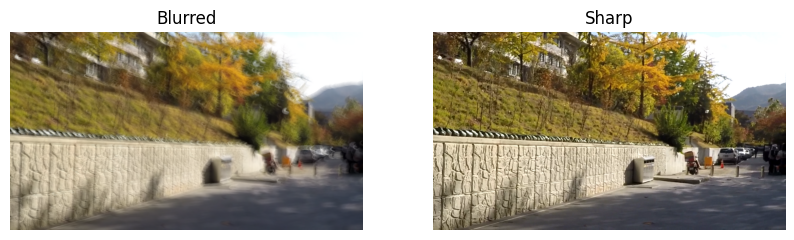

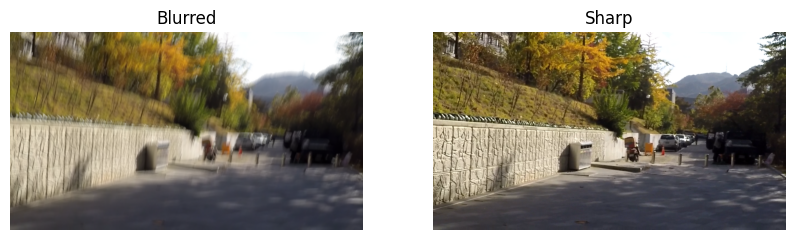

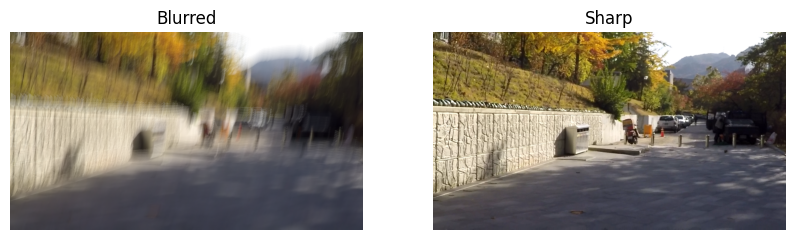

In [22]:
for i in range(3):
    filename = blurred_images[i]

    b_img = cv2.imread(os.path.join(blurred_path, filename))
    s_img = cv2.imread(os.path.join(sharp_path, filename))

    b_img = cv2.cvtColor(b_img, cv2.COLOR_BGR2RGB)
    s_img = cv2.cvtColor(s_img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(b_img)
    plt.title("Blurred")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(s_img)
    plt.title("Sharp")
    plt.axis("off")

    plt.show()

In [23]:
!pip install scipy


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In this section, a classical image deblurring method is applied to blurred images from the GoPro dataset. The goal is to restore image sharpness and then compare the restored outputs with the corresponding ground truth sharp images. The restored results will later be evaluated using both visual comparison and quantitative metrics such as PSNR and SSIM.

In [25]:
import numpy as np
import cv2
from scipy.signal import convolve2d

def motion_blur_kernel(size=15):
    kernel = np.zeros((size, size))
    kernel[size // 2, :] = np.ones(size)
    kernel = kernel / kernel.sum()
    return kernel

def richardson_lucy(image, kernel, iterations=10):
    image = image.astype(np.float32) / 255.0
    estimate = np.full(image.shape, 0.5, dtype=np.float32)
    kernel_mirror = np.flipud(np.fliplr(kernel))

    for _ in range(iterations):
        conv_est = convolve2d(estimate, kernel, mode='same', boundary='symm')
        conv_est[conv_est == 0] = 1e-6
        relative_blur = image / conv_est
        estimate *= convolve2d(relative_blur, kernel_mirror, mode='same', boundary='symm')

    estimate = np.clip(estimate, 0, 1)
    return (estimate * 255).astype(np.uint8)

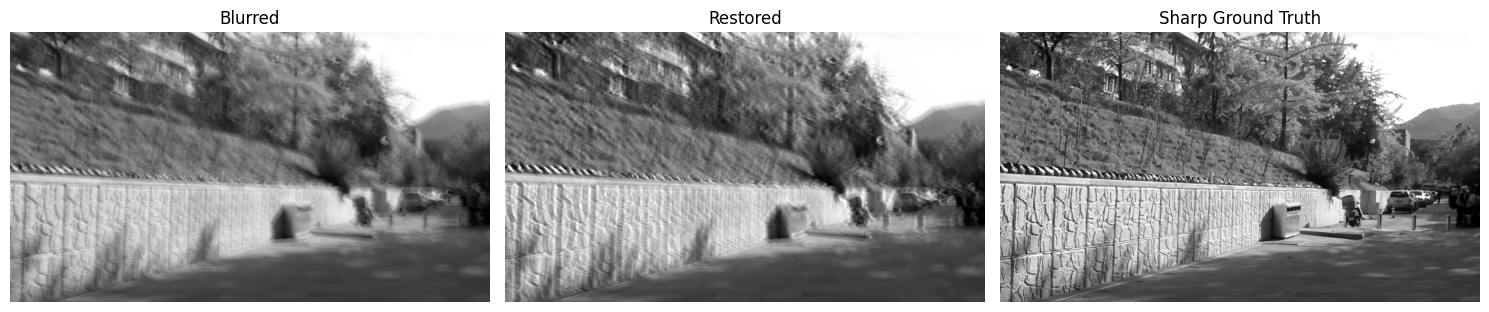

In [26]:
sample_file = blurred_images[0]

bgr = cv2.imread(os.path.join(blurred_path, sample_file), cv2.IMREAD_GRAYSCALE)
sharp_gray = cv2.imread(os.path.join(sharp_path, sample_file), cv2.IMREAD_GRAYSCALE)

kernel = motion_blur_kernel(size=15)
restored = richardson_lucy(bgr, kernel, iterations=10)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(bgr, cmap="gray")
plt.title("Blurred")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(restored, cmap="gray")
plt.title("Restored")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(sharp_gray, cmap="gray")
plt.title("Sharp Ground Truth")
plt.axis("off")

plt.tight_layout()
plt.show()

In [27]:
import time

kernel = motion_blur_kernel(size=15)
processing_times = []

for filename in tqdm(blurred_images):
    img_gray = cv2.imread(os.path.join(blurred_path, filename), cv2.IMREAD_GRAYSCALE)

    start = time.time()
    restored = richardson_lucy(img_gray, kernel, iterations=10)
    end = time.time()

    processing_times.append(end - start)

    cv2.imwrite(os.path.join(deblurred_path, filename), restored)

print("Deblurring complete")
print("Average processing time per image:", np.mean(processing_times), "seconds")

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [54:01<00:00, 32.41s/it]

Deblurring complete
Average processing time per image: 32.3605054140091 seconds


In [28]:
psnr_values = []
ssim_values = []

for filename in blurred_images:
    deblur_img = cv2.imread(os.path.join(deblurred_path, filename), cv2.IMREAD_GRAYSCALE)
    sharp_img = cv2.imread(os.path.join(sharp_path, filename), cv2.IMREAD_GRAYSCALE)

    p = psnr(sharp_img, deblur_img)
    s = ssim(sharp_img, deblur_img)

    psnr_values.append(p)
    ssim_values.append(s)

print("Average PSNR:", np.mean(psnr_values))
print("Average SSIM:", np.mean(ssim_values))

Average PSNR: 24.831372647958684
Average SSIM: 0.7467461897619461


The Richardson–Lucy deconvolution algorithm was used as a classical baseline for image deblurring. The restored images showed noticeable improvement over the blurred inputs, especially around edges and object boundaries, but they did not fully match the corresponding sharp ground truth images. This is expected because deblurring is an ill-posed problem and some information lost during motion blur cannot be perfectly recovered.

The quantitative evaluation produced an average PSNR of **24.83 dB** and an average SSIM of **0.7467**, indicating moderate similarity between the restored images and the ground truth sharp images. In terms of computational cost, the method required an average of **32.36 seconds per image**, showing that while the restoration quality is reasonable, the algorithm is relatively slow for large-scale or real-time use.

In [29]:
results_df = pd.DataFrame({
    "Image": blurred_images,
    "PSNR": psnr_values,
    "SSIM": ssim_values
})

results_df.to_csv(os.path.join(output_path, "deblurring_metrics.csv"), index=False)
results_df.head()

,Image,PSNR,SSIM
0,0.png,19.289492,0.398988
1,1.png,19.944995,0.485682
2,10.png,19.622386,0.496331
3,100.png,25.294934,0.764438
4,1000.png,28.201621,0.845045


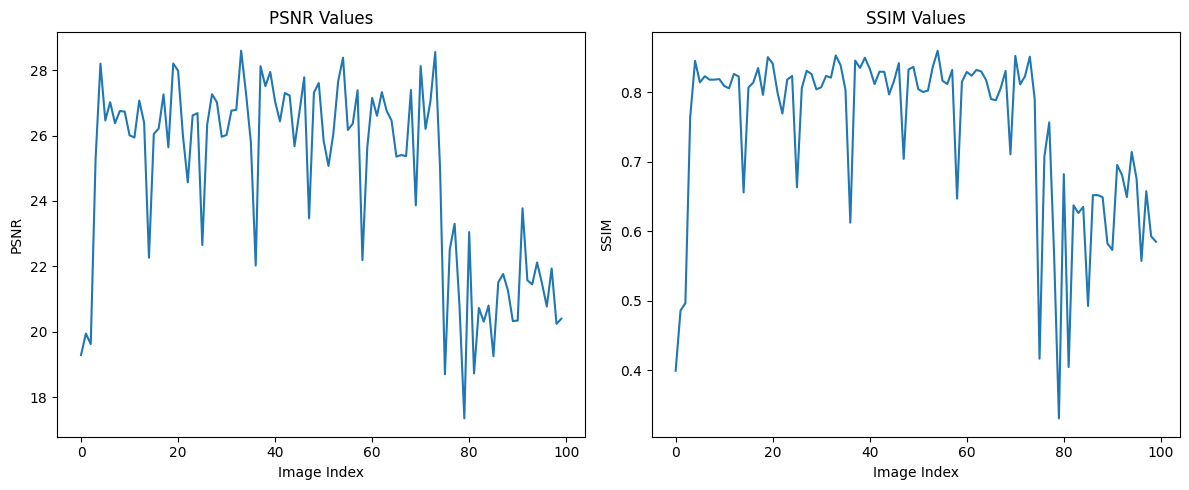

In [30]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(psnr_values)
plt.title("PSNR Values")
plt.xlabel("Image Index")
plt.ylabel("PSNR")

plt.subplot(1,2,2)
plt.plot(ssim_values)
plt.title("SSIM Values")
plt.xlabel("Image Index")
plt.ylabel("SSIM")

plt.tight_layout()
plt.savefig(os.path.join(output_path, "psnr_ssim_plot.png"), dpi=300)
plt.show()